### Approval Anomaly at ClearCheck Technologies
A Data-Driven Decision Making Case Study Using Python

## 1. Business Problem

ClearCheck Technologies works in remote diagnostics. Customers submit digital scans of a device,
and a licensed technician must review and approve each one before any remote update is authorized.
A careless approval is not a paperwork error -- it can expose a customer to a cyber-attack, a data
breach, or financial theft.

Technicians are paid **per case**. Administrators have started to wonder whether some of them are
reviewing thoroughly, or simply approving as fast as possible to maximize earnings. An attorney is
exploring a class-action suit that could cost the company millions.

This notebook works from 15 months of approval records from three technicians -- Gary Arnold,
Juan Mendez, and Matt Shawn -- with three columns each: a case number, a timestamp, and a
technician name. The job is to turn that into **evidence** -- for or against the negligence claim -- while being explicit about
what the evidence can and cannot establish.

## 2. Case Study Roadmap

```
Business Problem
        |
        v
Understand the Data
        |
        v
Data Preparation (derive duration + block features)
        |
        v
Exploratory Data Analysis (Q1: distribution of review durations)
        |
        v
Statistical Testing (Q2: one-sample t-tests vs. industry standards)
        |
        v
Batch/Block Analysis (Q3: is the "batch approval" defense true?)
        |
        v
Payout Policy Analysis (Q4: did the $50 -> $17 cut change behavior?)
        |
        v
Business Insights & Recommendations
```

## 3. Understanding the Data

ClearCheck provided 15 Excel extracts -- one per technician-month on file -- each with three
columns: `CASE_NUMBER`, `APPROVAL_DATE`, and `Technician` (column names and types vary slightly
across files, normalized below). **Only approvals are recorded** -- there is no
information about rejected cases, no record of what happened between two approvals, and no way to
see any pre-review work if it occurred.

In [1]:
# Import required libraries
# Data manipulation
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
import numpy as np
import pandas as pd

# Statistics
from scipy import stats

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

import warnings
warnings.filterwarnings("ignore")

import data_pipeline as dp
import analysis as an

In [2]:
# Load and normalize all 15 technician extracts
raw = dp.load_raw()
print("Raw rows:", raw.shape)
raw.head()

Raw rows: (64230, 4)


,CASE_NUMBER,APPROVAL_DATE,Technician,source_file
0,C327bc5ef27d75,2019-02-19 10:02:49,Gary Arnold,Arnold 001.xlsx
1,C9cc8268c0d75f,2019-02-19 13:45:44,Gary Arnold,Arnold 001.xlsx
2,C484d8e6d0448b,2019-02-22 06:21:49,Gary Arnold,Arnold 001.xlsx
3,C2f3a937707f28,2019-02-26 11:21:24,Gary Arnold,Arnold 001.xlsx
4,C294dc275d81c5,2019-02-20 12:13:51,Gary Arnold,Arnold 001.xlsx


In [3]:
# Sanity check -- missing values and coverage per technician
print(raw.isnull().sum())
print()
print(raw.groupby("Technician")["APPROVAL_DATE"].agg(["min", "max", "count"]))

CASE_NUMBER      0
APPROVAL_DATE    0
Technician       0
source_file      0
dtype: int64

                            min                 max  count
Technician                                                
Gary Arnold 2019-02-01 10:04:27 2021-09-30 17:01:34  42646
Juan Mendez 2019-02-01 09:15:47 2019-11-30 21:12:44  17469
Matt Shawn  2019-02-01 08:18:17 2019-02-28 17:05:42   4115


**Discussion.** The 15 extracts do **not** form one continuous 15-month window for every
technician. Gary Arnold has files from Feb-Nov 2019 and Jan-Sep 2021; Juan Mendez has files from
Feb-Nov 2019 only; Matt Shawn has a single file from Feb 2019. This matters directly for Q4 below
(the payout-change comparison), where only Arnold's data spans both sides of the June 2020 change.
This is a limitation of the extracts provided, not a finding about Mendez's or Shawn's behavior.

## 4. Data Preparation

Raw timestamps are not yet analysis-ready. Following the case's own definitions, this notebook derives:

- **Duration**: the gap, in seconds, between an approval and the immediately preceding approval by
  the same technician (the first approval on file for each technician has no duration).
- **Block**: a run of consecutive approvals with every gap under 10 minutes. A new block starts
  whenever a gap is >= 10 minutes (or at a technician's first approval on file).
- **Within-block gap**: the duration for a case that *continues* an existing block -- excluding
  each block's opening case, whose raw duration reflects the gap since the *previous* session, not
  review time inside the current one.

In [4]:
df = dp.build_features(raw)
blocks = dp.build_blocks(df)

print(f"Approvals: {len(df):,} rows across {df['Technician'].nunique()} technicians")
print(f"Blocks:    {len(blocks):,}")
df[["CASE_NUMBER", "Technician", "APPROVAL_DATE", "duration_sec", "block_key"]].head()

Approvals: 64,230 rows across 3 technicians
Blocks:    2,807


,CASE_NUMBER,Technician,APPROVAL_DATE,duration_sec,block_key
0,C5c8bc0c2dbb6a,Gary Arnold,2019-02-01 10:04:27,NaN,Gary Arnold_1
1,C1188f1e1dc09f,Gary Arnold,2019-02-01 10:04:31,4.0,Gary Arnold_1
2,C3d7e298e6f187,Gary Arnold,2019-02-01 10:04:35,4.0,Gary Arnold_1
3,Cdbc65218dc612,Gary Arnold,2019-02-01 10:04:39,4.0,Gary Arnold_1
4,C1604-CERVAM-646381,Gary Arnold,2019-02-01 10:04:44,5.0,Gary Arnold_1


## 5. Exploratory Data Analysis

### Q1) How long is a review, and how is it distributed per technician?

**Business Question.** Before running any formal test, it helps to understand the shape of the
duration data for each technician: is it skewed, and how many approvals land under 2, 5, 10, 30,
and 60 seconds?

In [5]:
dur_summary = an.duration_summary(df)
dur_summary.round(2)

,Technician,n_approvals,n_with_duration,mean_sec,median_sec,std_sec,cv,ci95_lower_sec,ci95_upper_sec,skew,min_sec,p90_sec,max_sec,pct_under_2s,pct_under_5s,pct_under_10s,pct_under_30s,pct_under_60s,pct_same_minute,pct_same_second
0,Gary Arnold,42646,42645,1969.89,4.0,191454.79,97.19,152.73,3787.04,157.70,0.0,46.0,34386056.0,4.96,53.04,77.20,86.57,91.59,91.59,0.63
1,Juan Mendez,17469,17468,1496.21,29.0,100505.26,67.17,5.67,2986.76,131.56,0.0,132.3,13264186.0,0.19,1.17,5.19,50.51,80.18,80.18,0.07
2,Matt Shawn,4115,4114,574.73,6.0,4664.93,8.12,432.14,717.32,11.93,0.0,84.0,83760.0,0.95,11.04,66.43,80.43,87.29,87.29,0.46


**Discussion.** All three distributions are strongly right-skewed (skewness far above the 0
expected for a symmetric distribution) -- a coefficient of variation (CV) near 1 or well above it
confirms extreme dispersion relative to the mean, the same CV diagnostic used in the Patelco
call-center case. The 95% confidence interval on the mean is *very* wide (e.g. roughly 150-3,800
seconds for Arnold), which on its own signals that the mean is not a trustworthy single summary
here -- a handful of multi-day gaps between shifts pull it far from the typical (median) approval.

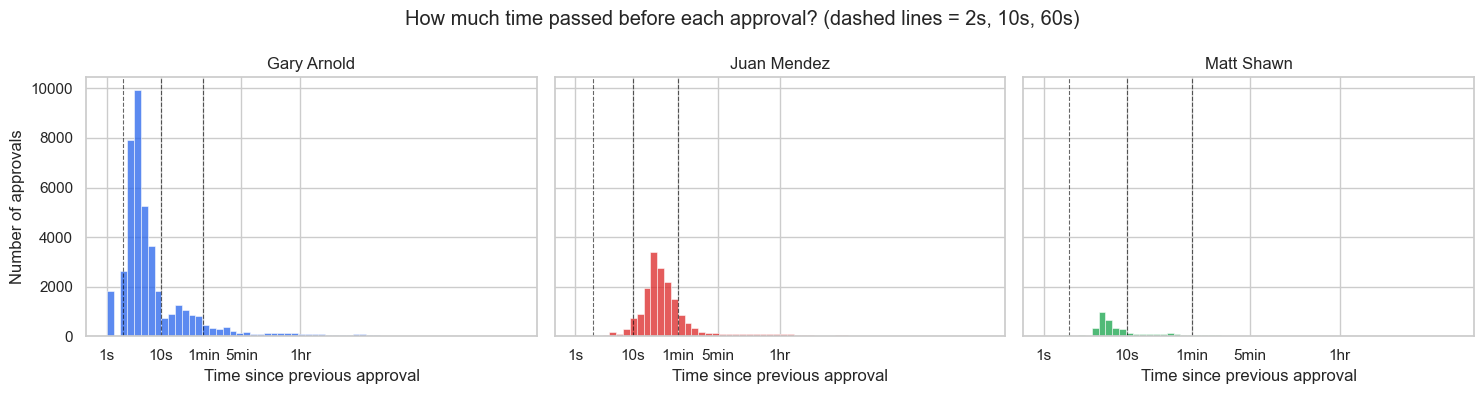

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
techs = ["Gary Arnold", "Juan Mendez", "Matt Shawn"]
colors = ["#2563eb", "#dc2626", "#16a34a"]
for ax, tech, c in zip(axes, techs, colors):
    d = df.loc[(df["Technician"] == tech) & df["duration_sec"].notna(), "duration_sec"]
    d = d[d > 0]
    sns.histplot(np.log10(d), bins=60, color=c, ax=ax)
    for t in [2, 10, 60]:
        ax.axvline(np.log10(t), color="black", ls="--", lw=0.8, alpha=0.6)
    ax.set_title(tech)
    time_ticks = [1, 10, 60, 300, 3600]
    ax.set_xticks(np.log10(time_ticks))
    ax.set_xticklabels(["1s", "10s", "1min", "5min", "1hr"])
    ax.set_xlabel("Time since previous approval")
axes[0].set_ylabel("Number of approvals")
fig.suptitle("How much time passed before each approval? (dashed lines = 2s, 10s, 60s)")
plt.tight_layout()
plt.show()

In [7]:
thresholds = [2, 5, 10, 30, 60]
threshold_pct = dur_summary.set_index("Technician")[[f"pct_under_{t}s" for t in thresholds]]
threshold_pct.columns = [f"< {t}s" for t in thresholds]
threshold_pct.round(1)

,< 2s,< 5s,< 10s,< 30s,< 60s
Technician,,,,,
Gary Arnold,5.0,53.0,77.2,86.6,91.6
Juan Mendez,0.2,1.2,5.2,50.5,80.2
Matt Shawn,0.9,11.0,66.4,80.4,87.3


**Business Interpretation.** Roughly 80-92% of approvals across all three technicians occur
within 60 seconds of the previous one. Gary Arnold has the highest share of extremely fast
approvals (about 5% under 2 seconds, over half under 5 seconds); Juan Mendez's approvals skew
slower; Matt Shawn sits between the two.

### Q2) Do they meet the standard? One-sample t-tests

**Business Question.** Industry experts suggest minimum average review times. This section tests, for each
technician, H0: mean duration = standard, against four standards (10, 5, 2, 1 minute).

In [8]:
one_sample = an.one_sample_tests(df)
one_sample

,Technician,standard_min,standard_sec,sample_mean_sec,n,t_stat,p_value_two_sided,p_value_one_sided_below,meets_standard,significantly_below
0,Gary Arnold,10,600,1969.886904,42645,1.477585,1.395262e-01,0.930237,True,False
1,Gary Arnold,5,300,1969.886904,42645,1.801171,7.168303e-02,0.964158,True,False
2,Gary Arnold,2,120,1969.886904,42645,1.995322,4.601411e-02,0.976993,True,False
3,Gary Arnold,1,60,1969.886904,42645,2.060039,3.940085e-02,0.980300,True,False
4,Juan Mendez,10,600,1496.211186,17468,1.178537,2.385987e-01,0.880701,True,False
5,Juan Mendez,5,300,1496.211186,17468,1.573043,1.157269e-01,0.942137,True,False
6,Juan Mendez,2,120,1496.211186,17468,1.809747,7.035221e-02,0.964824,True,False
7,Juan Mendez,1,60,1496.211186,17468,1.888648,5.895553e-02,0.970522,True,False
8,Matt Shawn,10,600,574.731405,4114,-0.347430,7.282858e-01,0.364143,False,False
9,Matt Shawn,5,300,574.731405,4114,3.777418,1.607032e-04,0.999920,True,False


**Discussion.** For Gary Arnold and Juan Mendez, this required test does **not** find average
review duration significantly below any of the four standards -- sample means for both sit at or
above every standard, so there is not statistically significant evidence, by this specific test,
that either falls short. Matt Shawn's mean falls significantly below the three shortest standards;
his data is a single month on file (4,115 approvals vs. 17,000-43,000 for the other two), worth
weighing when judging how representative that is. Technical caveat, for balance: the extreme skew
documented in Q1 widens the standard error and works against finding significance in either
direction, so Arnold's and Mendez's results here should be read as "this test does not find a
shortfall," not as strong proof review time is adequate -- the median and threshold figures in Q1
are a useful complementary, less outlier-prone view of the same question.

### Q3) Is the batch-approval defense true?

**Business Question.** Technicians say fast approvals are real: they pre-review several cases --
often ten, fifteen, or twenty at a time, by their account -- then sit down and enter the results
one after another. A block is defined as a run of approvals with gaps under 10 minutes, treated as
one such session, to see whether the data is consistent with that account.

In [9]:
block_summary = an.block_summary(blocks)
block_summary.round(2)

,Technician,n_blocks,n_single_case_blocks,n_multi_case_blocks,avg_cases_per_block,median_cases_per_block,max_cases_per_block,avg_sec_per_case_in_block,median_sec_per_case_in_block,pct_blocks_under_2s_per_case,pct_blocks_under_5s_per_case
0,Gary Arnold,1556,119,1437,27.41,11.0,233,20.30,11.03,0.35,13.01
1,Juan Mendez,1075,161,914,16.25,6.0,177,57.35,39.92,0.00,0.00
2,Matt Shawn,176,24,152,23.38,8.0,206,42.31,23.90,0.00,0.00


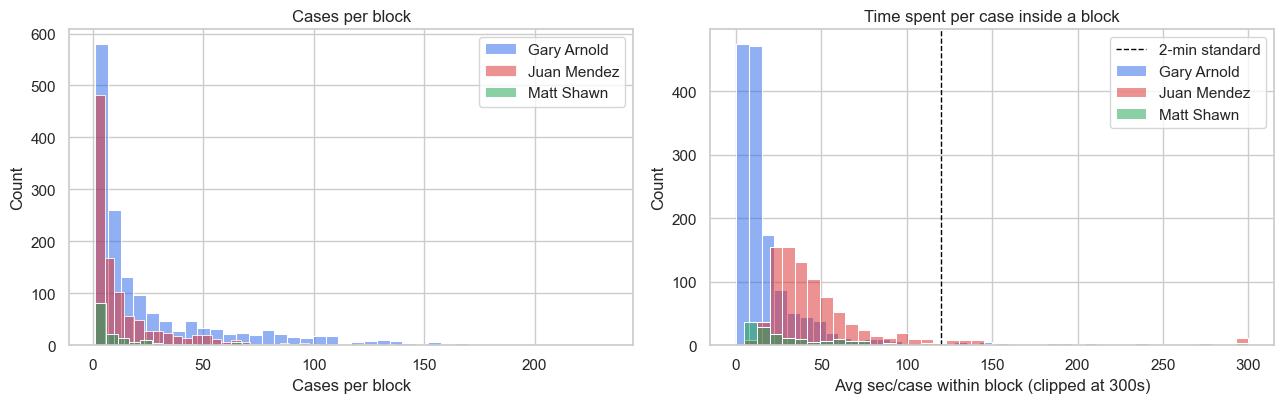

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for tech, c in zip(techs, colors):
    b = blocks.loc[blocks["Technician"] == tech, "cases_in_block"]
    sns.histplot(b, bins=40, alpha=0.5, label=tech, color=c, ax=axes[0])
axes[0].set_xlabel("Cases per block"); axes[0].set_title("Cases per block"); axes[0].legend()

for tech, c in zip(techs, colors):
    b = blocks.loc[(blocks["Technician"] == tech) & (blocks["cases_in_block"] > 1), "avg_duration_sec"].dropna()
    sns.histplot(np.clip(b, 0, 300), bins=40, alpha=0.5, label=tech, color=c, ax=axes[1])
axes[1].axvline(120, color="black", ls="--", lw=1, label="2-min standard")
axes[1].set_xlabel("Avg sec/case within block (clipped at 300s)")
axes[1].set_title("Time spent per case inside a block")
axes[1].legend()
plt.tight_layout()
plt.show()

**Business Interpretation.** Blocks are real and often substantial: technicians average 16-27
cases per block (median 6-11), with some blocks exceeding 200 cases -- squarely in the range the
technicians describe, and hard to explain any other way: there is no obvious operational reason to
approve dozens of unrelated cases within minutes of each other unless they were handled as a batch.

A simple back-of-envelope check: take the median batch size for each technician (Arnold 11 cases,
Mendez 6, Shawn 8) and assume a realistic, unhurried 60-90 seconds of genuine review per case, done
off-system before any approval is clicked. That puts a typical pre-review phase at roughly 11-16
minutes for Arnold, 6-9 for Mendez, and 8-12 for Shawn -- comfortably inside several of the Q2
standards. Once that phase is done, logging already-decided results would naturally take just
seconds per case -- exactly the pattern the within-block timestamps show (median 11s / 40s / 24s
for Arnold / Mendez / Shawn). These numbers describe the data-entry step, not the review step, and
the review step -- if it happened as described -- would be invisible to this dataset by
construction. This is not proof the pre-review happened, but the batch sizes, the lack of a more
plausible alternative explanation, and a realistic review pace fitting comfortably inside the
observed windows make the technicians' account a credible, consistent reading of this data.

### Q4) Did the money change behavior? Payout policy analysis

**Business Question.** Per-approval pay dropped from \$50 to \$17 on June 1, 2020. This section
compares review durations before and after with a two-sample t-test.

In [11]:
coverage = df.groupby("Technician")["APPROVAL_DATE"].agg(["min", "max"])
coverage["spans_payout_change"] = (coverage["min"] < dp.PAYOUT_CHANGE_DATE) & (coverage["max"] >= dp.PAYOUT_CHANGE_DATE)
coverage

,min,max,spans_payout_change
Technician,,,
Gary Arnold,2019-02-01 10:04:27,2021-09-30 17:01:34,True
Juan Mendez,2019-02-01 09:15:47,2019-11-30 21:12:44,False
Matt Shawn,2019-02-01 08:18:17,2019-02-28 17:05:42,False


**Discussion.** Only **Gary Arnold**'s extracts include approvals on both sides of the payout
change; Mendez's and Shawn's files are entirely from 2019. A before/after comparison can only be
computed for Arnold from this dataset.

In [12]:
payout = an.payout_change_tests(df)
payout

,Technician,n_pre,n_post,mean_pre_sec,mean_post_sec,median_pre_sec,median_post_sec,has_both_periods,t_stat,p_value,significant_change_ttest,mannwhitney_u,mannwhitney_p,significant_change_mannwhitney
0,Gary Arnold,12603,30042,2069.674046,1928.024932,5.0,4.0,True,0.075536,0.939789,False,247049744.0,0.0,True
1,Juan Mendez,17468,0,1496.211186,NaN,29.0,NaN,False,NaN,NaN,False,NaN,NaN,False
2,Matt Shawn,4114,0,574.731405,NaN,6.0,NaN,False,NaN,NaN,False,NaN,NaN,False


In [13]:
# Did batch size itself change after the pay cut? (Arnold only, per the coverage limit above)
arnold_blocks = blocks[blocks["Technician"] == "Gary Arnold"]
arnold_blocks.groupby("period")["cases_in_block"].agg(["count", "mean", "median"])

,count,mean,median
period,,,
Post-change ($17),1033,29.082285,11.0
Pre-change ($50),523,24.099426,11.0


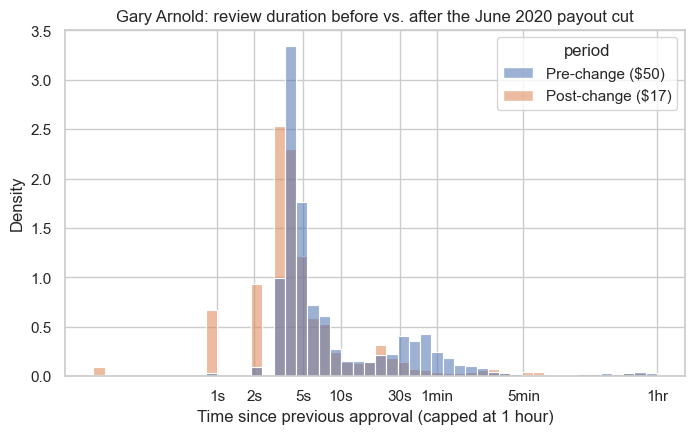

In [14]:
arnold = df.loc[(df["Technician"] == "Gary Arnold") & df["duration_sec"].notna()].copy()
arnold = arnold[arnold["duration_sec"] < 3600]
arnold["log_duration"] = np.log10(arnold["duration_sec"].clip(lower=0.1))

plt.figure(figsize=(8, 4.5))
sns.histplot(
    data=arnold, x="log_duration", hue="period", stat="density",
    common_norm=False, bins=50, alpha=0.55,
)
time_ticks = [1, 2, 5, 10, 30, 60, 300, 3600]
plt.xticks(np.log10(time_ticks), ["1s", "2s", "5s", "10s", "30s", "1min", "5min", "1hr"])
plt.xlabel("Time since previous approval (capped at 1 hour)")
plt.title("Gary Arnold: review duration before vs. after the June 2020 payout cut")
plt.show()

**Business Interpretation.** On the required Welch two-sample t-test, there is **no significant
difference** (p ~ 0.94) -- both periods contain a handful of extremely long, multi-day gaps that
dominate the variance. A supplementary, distribution-free **Mann-Whitney U test**, run here as
extra diligence rather than a replacement for the required test, does find a small, real shift in
the median: 5 seconds to 4 seconds. On its own that is a modest effect, not obviously evidence of a
change in review quality.

A more plausible reading, and one the data actively supports: Arnold's average batch size grew from
about 24 cases per sitting before the pay cut to about 29 after it -- roughly a 20% increase. If
per-case pay was cut by roughly two-thirds, reviewing modestly larger batches per sitting to
protect total earnings is a straightforward, rational response that does not require assuming any
individual case was reviewed less carefully -- and it is easily enough, on its own, to explain a
one-second faster median entry pace.

## 6. Additional KPIs

Beyond the metrics requested directly by the case, this analysis also tracks:

- **Fast-approval ratio** (% of approvals under 2/5/10/30/60 seconds) -- the clearest,
  outlier-resistant measure of how often a technician approves near-instantly.
- **Block frequency and size** (blocks per technician, cases/block) -- how work is structured into
  sessions.
- **Within-block vs. cross-block seconds/case** -- separates "time inside a working session" from
  "time between sessions," which the raw duration column conflates.
- **Top approval days and hourly volume** -- surfaces unusually high-volume days worth a manual,
  case-level audit.

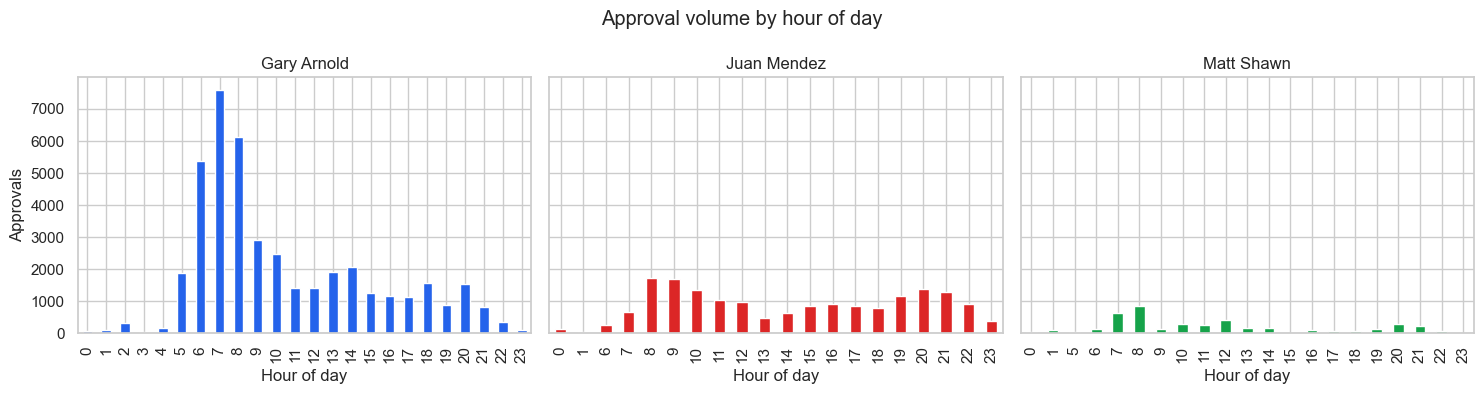

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tech, c in zip(axes, techs, colors):
    g = df.loc[df["Technician"] == tech]
    g["hour"].value_counts().sort_index().plot(kind="bar", ax=ax, color=c)
    ax.set_title(tech); ax.set_xlabel("Hour of day")
axes[0].set_ylabel("Approvals")
fig.suptitle("Approval volume by hour of day")
plt.tight_layout()
plt.show()

## 7. Business Insights & Recommendations

Taken together, the evidence in this notebook leans toward supporting the technicians' account,
without fully proving it. The batch-review explanation is a credible, internally-consistent reading
of the data -- not the only conceivable one, but the one the numbers best fit.

**What the evidence demonstrates**
- Batch sizes closely match the technicians' own description of the practice (median 6-11 cases,
  average 16-27 per sitting) -- a pattern with no obvious alternative explanation.
- The required one-sample t-test does not find Arnold's or Mendez's average review duration to be
  significantly below any of the four industry standards.
- A modest, realistic per-case review pace (60-90 seconds) fits comfortably inside a typical batch
  window for all three technicians, before any approval would even be logged.

**What the evidence suggests, but does not prove**
- That the pre-review described by the technicians actually took place and was thorough -- the
  batch-size and timing arithmetic is consistent with this, but this dataset cannot see anything
  that happened off-system.
- That Arnold's larger batch sizes after the payout cut reflect a rational adjustment to lower pay
  (more cases per sitting) rather than reduced diligence -- plausible, not something timestamps
  alone can settle.

**What the evidence cannot resolve**
- Whether the claimed pre-review actually happened, or how thorough it was, for any individual case
  or technician.
- The outcome or quality of any review -- there is no record of rejected cases.
- Matt Shawn's standing relative to the others, given his file covers a single month (4,115
  approvals) versus 15-43 months of combined coverage for Arnold and Mendez.

**Recommendations**
1. Lead with the batch-size and required-t-test findings (Q3-Q4), the strongest direct support for
   the technicians' account; use the median/threshold figures in Q1 as context, not as a
   standalone case against them.
2. Ask technicians to document their pre-review process going forward (a simple log or checklist
   per batch) so future data can directly verify what this dataset can only infer indirectly.
3. Instrument the review portal to log time-on-case directly, which would settle the central
   question this analysis cannot.
4. Obtain continuous monthly extracts for all three technicians spanning the payout change, so the
   before/after comparison -- currently only possible for Arnold -- can be run for Mendez and Shawn.
5. Treat Matt Shawn's single-month sample with caution in any broader conclusion; request
   additional months before drawing firm comparisons between him and the other two.